# Taller Análisis Exploratorio de Datos

## Paso 1: Carga de datos

Abra el archivo en Excel o bloc de notas, y revise sí hay algo particular con los datos. Este paso es importante para evitar problemas posteriores al cargar los datos.

Cargar el archivo dado, que contiene un dataset cuya información puede consultar en [UCI](https://archive.ics.uci.edu/dataset/27/credit+approval).

De a las columnas los siguientes nombres: 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15'.

Responda las siguientes preguntas:

- ¿Cuántas filas y columnas tiene el dataframe?
- ¿De qué tipo de dato es cada columna?
- ¿Las variables están en el tipo de dato correcto para su contenido?


In [ ]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path("/content")

file_path = "sample_data/crx.data"

df = pd.read_csv(
    DATA_DIR / file_path,
    header=None,
    na_values='?'
    )
df.columns = [
    'A0', 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15'
]

df.head()

,A0,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,202.0,0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,43.0,560,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,280.0,824,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,100.0,3,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,120.0,0,+


## Comprobamos el tipo de datos

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A0      678 non-null    object 
 1   A1      678 non-null    float64
 2   A2      690 non-null    float64
 3   A3      684 non-null    object 
 4   A4      684 non-null    object 
 5   A5      681 non-null    object 
 6   A6      681 non-null    object 
 7   A7      690 non-null    float64
 8   A8      690 non-null    object 
 9   A9      690 non-null    object 
 10  A10     690 non-null    int64  
 11  A11     690 non-null    object 
 12  A12     690 non-null    object 
 13  A13     677 non-null    float64
 14  A14     690 non-null    int64  
 15  A15     690 non-null    object 
dtypes: float64(4), int64(2), object(10)
memory usage: 86.4+ KB


Corregimos el tipo de datos

In [ ]:
df = df.astype({'A13':'Int64'})

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A0      678 non-null    object 
 1   A1      678 non-null    float64
 2   A2      690 non-null    float64
 3   A3      684 non-null    object 
 4   A4      684 non-null    object 
 5   A5      681 non-null    object 
 6   A6      681 non-null    object 
 7   A7      690 non-null    float64
 8   A8      690 non-null    object 
 9   A9      690 non-null    object 
 10  A10     690 non-null    int64  
 11  A11     690 non-null    object 
 12  A12     690 non-null    object 
 13  A13     677 non-null    Int64  
 14  A14     690 non-null    int64  
 15  A15     690 non-null    object 
dtypes: Int64(1), float64(3), int64(2), object(10)
memory usage: 87.1+ KB


- El dataframe tiene 16 columnas y 690 filas
- Las columnas A0,A3,A4,A5,A6,A8,A9,A11,A12,A15 son de tipo objeto, es decir de tipo string. Las columnas A1,A2,A7,A13 son de tipo float. Las columnas A10,A14 son de tipo entero; todo esto con el cambio de "?" a "NaN"
- No, algunos tipos de datos de las variables no corresponden a su contenido, luego aplicamos el intercambio de tipo de variable para corregir el dataframe y cambiamos también el de la columna A13 la cual estaba en float a int

## Paso 2: Exploración inicial de los datos

Responda las siguientes preguntas:

- ¿Hay valores fuera de rango o imposibles, según el dominio del problema?
- ¿Hay variables que no varían?
- Qué variables *cualitativas* tienen muchos valores únicos (alta cardinalidad)?
- ¿Hay claves primarias o identificadores únicos?

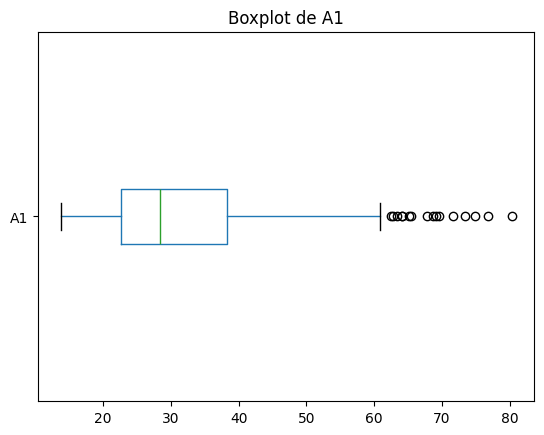

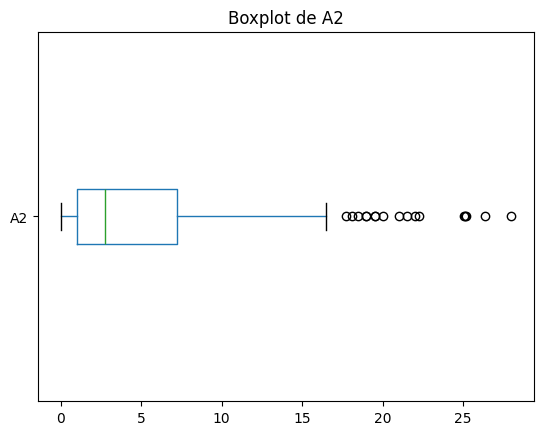

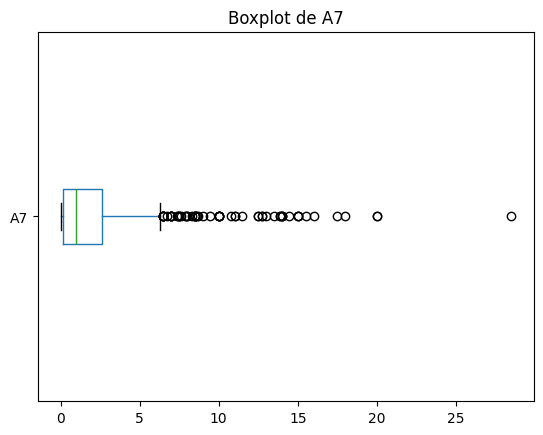

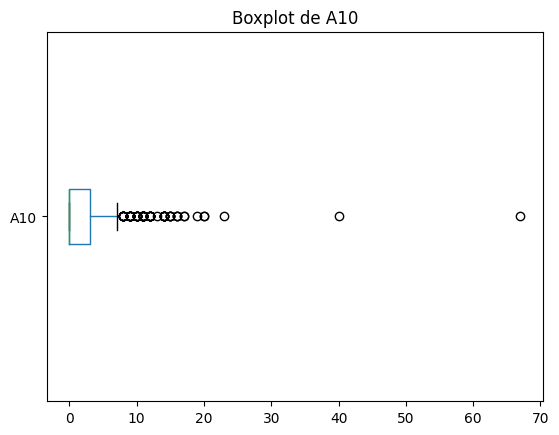

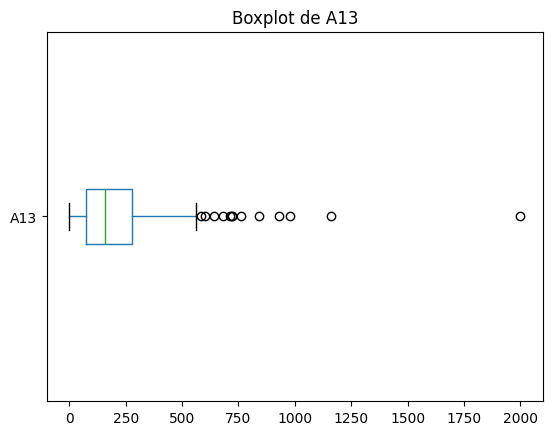

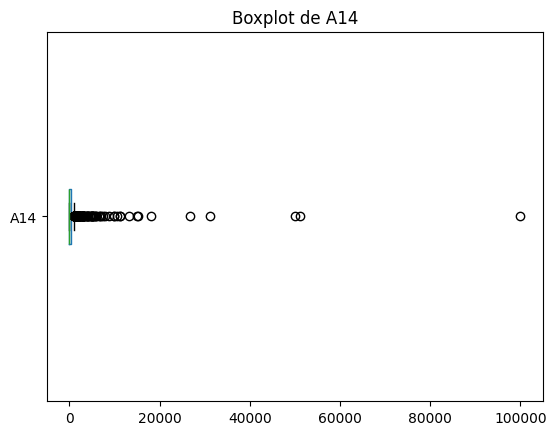

In [ ]:
import matplotlib.pyplot as plt

num_vars = df.select_dtypes(include=["number"]).columns

for num in num_vars:
    plt.figure()
    df.boxplot(column=num, grid=False, vert=False)
    plt.title(f'Boxplot de {num}')
    plt.show()

Variables numéricas:  Index(['A1', 'A2', 'A7', 'A10', 'A13', 'A14'], dtype='object')


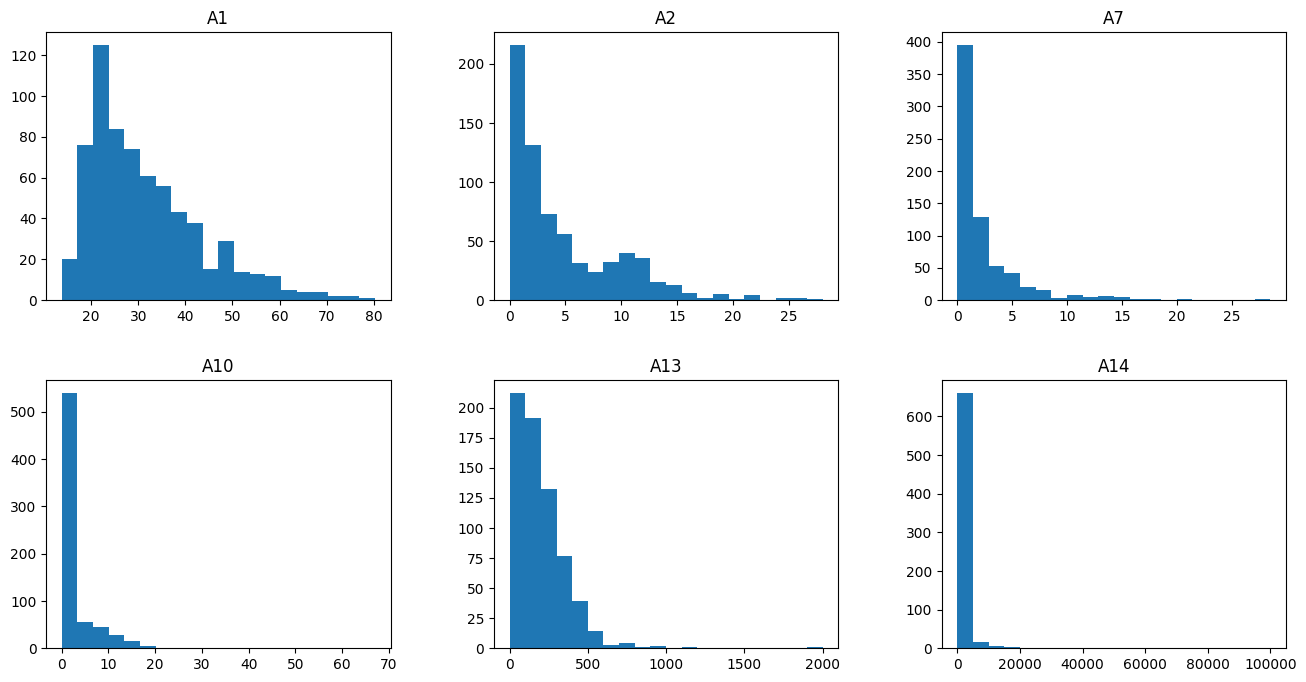

In [ ]:
num_vars = df.select_dtypes(include=["number"]).columns
print('Variables numéricas: ', num_vars)

df.hist(figsize=(16, 8), bins=20, layout=(2,3), grid=False, sharex=False, sharey=False);

In [ ]:
print(df.select_dtypes(include='number').columns)

cuantitativas = df.select_dtypes(include='number')

for col in cuantitativas.columns:
    print(f"{col}: {cuantitativas[col].nunique()} valores únicos de {len(df)} registros")

Index(['A1', 'A2', 'A7', 'A10', 'A13', 'A14'], dtype='object')
A1: 349 valores únicos de 690 registros
A2: 215 valores únicos de 690 registros
A7: 132 valores únicos de 690 registros
A10: 23 valores únicos de 690 registros
A13: 170 valores únicos de 690 registros
A14: 240 valores únicos de 690 registros


Variables Cualitativas

In [ ]:
df.describe(include='object')

,A0,A3,A4,A5,A6,A8,A9,A11,A12,A15
count,678,684,684,681,681,690,690,690,690,690
unique,2,3,3,14,9,2,2,2,3,2
top,b,u,g,c,v,t,f,f,g,-
freq,468,519,519,137,399,361,395,374,625,383


In [ ]:
cat_vars = df.select_dtypes(include=['object']).columns

for var in cat_vars:
    print(f'El conteo de la variable {var} es: \n {df[var].value_counts()} \n')

El conteo de la variable A0 es: 
 A0
b    468
a    210
Name: count, dtype: int64 

El conteo de la variable A3 es: 
 A3
u    519
y    163
l      2
Name: count, dtype: int64 

El conteo de la variable A4 es: 
 A4
g     519
p     163
gg      2
Name: count, dtype: int64 

El conteo de la variable A5 es: 
 A5
c     137
q      78
w      64
i      59
aa     54
ff     53
k      51
cc     41
x      38
m      38
d      30
e      25
j      10
r       3
Name: count, dtype: int64 

El conteo de la variable A6 es: 
 A6
v     399
h     138
bb     59
ff     57
j       8
z       8
dd      6
n       4
o       2
Name: count, dtype: int64 

El conteo de la variable A8 es: 
 A8
t    361
f    329
Name: count, dtype: int64 

El conteo de la variable A9 es: 
 A9
f    395
t    295
Name: count, dtype: int64 

El conteo de la variable A11 es: 
 A11
f    374
t    316
Name: count, dtype: int64 

El conteo de la variable A12 es: 
 A12
g    625
s     57
p      8
Name: count, dtype: int64 

El conteo de la variable 

## Respuestas Pregunta 2
- No, los valores no están fuera de rango ni imposibles, los datos están bien
- Según la función describe, no encontramos variables que no varíen ya que todas tienen mínimo 2 valores diferentes en los registros totales
- La variable que tiene alta cardinalidad es A5 con 14 valores únicos
- No, no hay identificadores únicos ya que podemos notar que los valores únicos que tiene cada variable son significativamente menores a el conteo total de los registros que tiene

## Paso 3: Identificación de datos duplicados, datos nulos y problemas de formateo

Descarte las variables que solo toman un valor y las que son clave primaria. También descarte las variables **City** y **Lat Long**.

Responda las siguientes preguntas:

- ¿Qué variables tienen valores nulos? ¿En qué proporción?
- ¿Hay registros duplicados?
- ¿Hay variables con problemas de formateo (fechas, monedas, mayúsculas/minúsculas)?

In [ ]:
nulos = df.isnull().sum()

In [ ]:
conteo = df.count()

In [ ]:
proporciones = {}
for i in range(len(nulos)):
  proporciones[i] = float((nulos[i] / conteo[i])*100)

for i in range(len(proporciones)):
  print(f"Proporción de A{i} = {proporciones[i]}")

Proporción de A0 = 1.7699115044247788
Proporción de A1 = 1.7699115044247788
Proporción de A2 = 0.0
Proporción de A3 = 0.8771929824561403
Proporción de A4 = 0.8771929824561403
Proporción de A5 = 1.3215859030837005
Proporción de A6 = 1.3215859030837005
Proporción de A7 = 0.0
Proporción de A8 = 0.0
Proporción de A9 = 0.0
Proporción de A10 = 0.0
Proporción de A11 = 0.0
Proporción de A12 = 0.0
Proporción de A13 = 1.9202363367799113
Proporción de A14 = 0.0
Proporción de A15 = 0.0


/tmp/ipykernel_721/3509865895.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  proporciones[i] = float((nulos[i] / conteo[i])*100)


In [ ]:
print('Número de registros duplicados: ', df.duplicated().sum())

Número de registros duplicados:  0


In [ ]:
Columnas = [
    'A0', 'A3', 'A4', 'A5', 'A6', 'A8', 'A9', 'A11', 'A12','A15'
]

for i in range(len(Columnas)):
  print(f"Valores únicos de {Columnas[i]}: {df[Columnas[i]].unique()}")


Valores únicos de A0: ['b' 'a' nan]
Valores únicos de A3: ['u' 'y' nan 'l']
Valores únicos de A4: ['g' 'p' nan 'gg']
Valores únicos de A5: ['w' 'q' 'm' 'r' 'cc' 'k' 'c' 'd' 'x' 'i' 'e' 'aa' 'ff' 'j' nan]
Valores únicos de A6: ['v' 'h' 'bb' 'ff' 'j' 'z' nan 'o' 'dd' 'n']
Valores únicos de A8: ['t' 'f']
Valores únicos de A9: ['t' 'f']
Valores únicos de A11: ['f' 't']
Valores únicos de A12: ['g' 's' 'p']
Valores únicos de A15: ['+' '-']


## Respuestas pregunta 3
- Las variables que identificamos tiene valores nulos son A0,A1,A3,A4,A5,A6 Y A13. La propoción fue de A0 = 1.7699115044247788, A1 = 1.7699115044247788, A3 = 0.8771929824561403, A4 = 0.8771929824561403, A5 = 1.3215859030837005, A6 = 1.3215859030837005, A13 = 1.9202363367799113 y las otras de 0
- Se observo que en el dataframe no hay registros duplicados
- En los datos obtenidos se observa que no hay problemas de formateo ya que los registros de cada columna siguen un formato estándar

## Paso 4: Análisis de variables cuantitativas

Haga análisis de normalidad de las variables cuantitativas. Indique cuáles variables cumplen con el supuesto de normalidad y cuáles no.

Haga un análisis gráfico de outliers, y como resultado de este indique que variables tienen datos atípicos.

Variables numéricas:  Index(['A1', 'A2', 'A7', 'A10', 'A13', 'A14'], dtype='object')


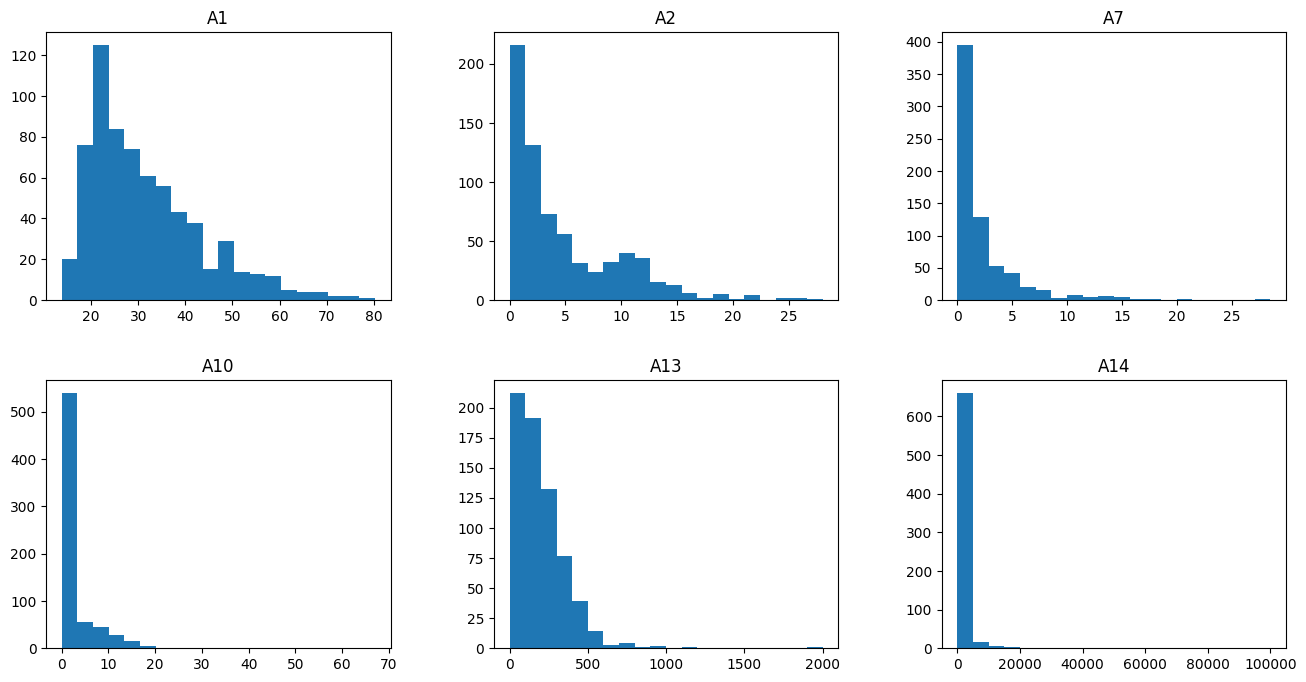

In [ ]:
num_vars = df.select_dtypes(include=["number"]).columns
print('Variables numéricas: ', num_vars)

df.hist(figsize=(16, 8), bins=20, layout=(2,3), grid=False, sharex=False, sharey=False);

In [ ]:
from scipy.stats import kstest

for num in num_vars:
    __, p_value = kstest(df[num], 'norm', args=(df[num].mean(), df[num].std()))
    print(f"Prueba de Kolmogorov-Smirnov para {num}:")
    print(f"  Valor p: {p_value}")
    if p_value > 0.05:
        print(f"  {num} parece ser normal (no se rechaza la hipótesis nula)")
    else:
        print(f"  {num} no parece ser normal (se rechaza la hipótesis nula)")
    print()

Prueba de Kolmogorov-Smirnov para A1:
  Valor p: nan
  A1 no parece ser normal (se rechaza la hipótesis nula)

Prueba de Kolmogorov-Smirnov para A2:
  Valor p: 1.3014031904956561e-18
  A2 no parece ser normal (se rechaza la hipótesis nula)

Prueba de Kolmogorov-Smirnov para A7:
  Valor p: 1.7508115416086583e-39
  A7 no parece ser normal (se rechaza la hipótesis nula)

Prueba de Kolmogorov-Smirnov para A10:
  Valor p: 1.0376830545783983e-59
  A10 no parece ser normal (se rechaza la hipótesis nula)

Prueba de Kolmogorov-Smirnov para A13:
  Valor p: nan
  A13 no parece ser normal (se rechaza la hipótesis nula)

Prueba de Kolmogorov-Smirnov para A14:
  Valor p: 2.9497270652247685e-112
  A14 no parece ser normal (se rechaza la hipótesis nula)



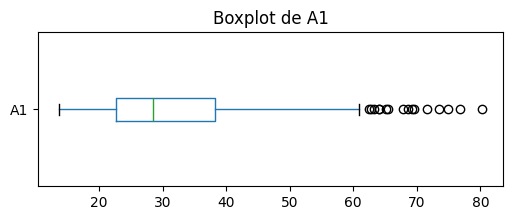

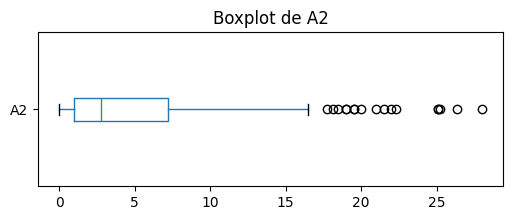

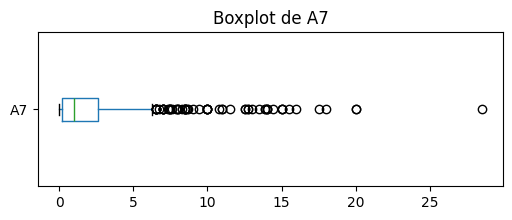

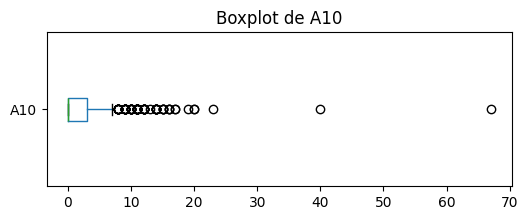

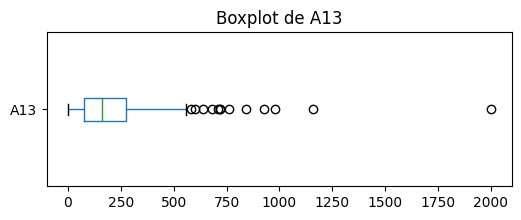

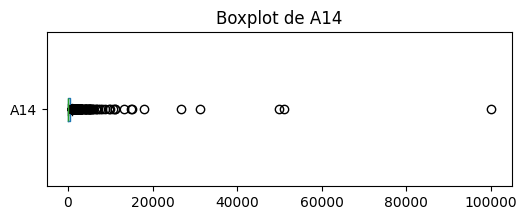

In [ ]:
import matplotlib.pyplot as plt

for num in num_vars:
    plt.figure(figsize=(6, 2))
    df.boxplot(column=num, grid=False, vert=False)
    plt.title(f'Boxplot de {num}')
    plt.show()

## Respuestas punto 4
- Se realizaron las gráficas para verificar si existen variables cuantitativas que tengan cumplen con normalidad y cuales no, se pudo observar que ninguna de las variables cumple con este supuesto; además se realizaron las pruebas de Kolmogorov-Smirnov para reafirmar el supuesto y se confirmo que ninguna es normal
- Se realizaron los diagramas de cajas y bigotes con los cuales se puede observar los outliers, se puede ver que A1 tiene grandes valores atípicos hacia la derecha por encima de 60,A2 valores atípicos mayores aproximadamente a 17,A7 gran cantidad de valores atípicos con algunos bastante alejados,A10 valores atípicos y unos bastante alejados,A13 valores atípicos incluyendo uno muy extremo cercano a 2000 y A14 varios valores atípicos y la caja se concentra mayormente en un valor

## Paso 5: Análisis de variables cualitativas

Responda a las siguientes preguntas:

- ¿Cómo se comportan las variables categóricas?
- ¿Existen variables de alta cardinalidad?
- ¿Existen categorías atípicas?

In [ ]:
cat_vars = df.select_dtypes(include=['object']).columns

for var in cat_vars:
    print(f'El conteo de la variable {var} es: \n {df[var].value_counts()} \n')

El conteo de la variable A0 es: 
 A0
b    468
a    210
Name: count, dtype: int64 

El conteo de la variable A3 es: 
 A3
u    519
y    163
l      2
Name: count, dtype: int64 

El conteo de la variable A4 es: 
 A4
g     519
p     163
gg      2
Name: count, dtype: int64 

El conteo de la variable A5 es: 
 A5
c     137
q      78
w      64
i      59
aa     54
ff     53
k      51
cc     41
x      38
m      38
d      30
e      25
j      10
r       3
Name: count, dtype: int64 

El conteo de la variable A6 es: 
 A6
v     399
h     138
bb     59
ff     57
j       8
z       8
dd      6
n       4
o       2
Name: count, dtype: int64 

El conteo de la variable A8 es: 
 A8
t    361
f    329
Name: count, dtype: int64 

El conteo de la variable A9 es: 
 A9
f    395
t    295
Name: count, dtype: int64 

El conteo de la variable A11 es: 
 A11
f    374
t    316
Name: count, dtype: int64 

El conteo de la variable A12 es: 
 A12
g    625
s     57
p      8
Name: count, dtype: int64 

El conteo de la variable 

### Proporciones

In [ ]:
for col in cat_vars:
    print(f"\n--- {col} ---")
    print(
        df[col]
        .value_counts(normalize=True, dropna=False)
        .mul(100)
        .round(2)
    )


--- A0 ---
A0
b      67.83
a      30.43
NaN     1.74
Name: proportion, dtype: float64

--- A3 ---
A3
u      75.22
y      23.62
NaN     0.87
l       0.29
Name: proportion, dtype: float64

--- A4 ---
A4
g      75.22
p      23.62
NaN     0.87
gg      0.29
Name: proportion, dtype: float64

--- A5 ---
A5
c      19.86
q      11.30
w       9.28
i       8.55
aa      7.83
ff      7.68
k       7.39
cc      5.94
m       5.51
x       5.51
d       4.35
e       3.62
j       1.45
NaN     1.30
r       0.43
Name: proportion, dtype: float64

--- A6 ---
A6
v      57.83
h      20.00
bb      8.55
ff      8.26
NaN     1.30
j       1.16
z       1.16
dd      0.87
n       0.58
o       0.29
Name: proportion, dtype: float64

--- A8 ---
A8
t    52.32
f    47.68
Name: proportion, dtype: float64

--- A9 ---
A9
f    57.25
t    42.75
Name: proportion, dtype: float64

--- A11 ---
A11
f    54.2
t    45.8
Name: proportion, dtype: float64

--- A12 ---
A12
g    90.58
s     8.26
p     1.16
Name: proportion, dtype: float64


- La variable A0 presenta una distribución principalmente concentrada en la categoría b, que representa aproximadamente 67,83% de los registros, mientras que a representa el 30,43%
- La variable A3 presenta una distribución principalmente concentrada en la categoría u, que representa aproximadamente 75,22% de los registros, mientras que y representa el 23,62%
- La variable A4 presenta una distribución principalmente concentrada en la categoría g, que representa aproximadamente 75,22% de los registros, mientras que p representa el 23,62%
- La variable A5 presenta una distribución principalmente concentrada en la categoría c, que representa aproximadamente 19,86% de los registros, mientras que q representa el 11,30% y el resto del porcentaje repartido en otras categorías
- La variable A6 presenta una distribución principalmente concentrada en la categoría v, que representa aproximadamente 57,83% de los registros, mientras que h representa el 20,00% y el resto del porcentaje repartido en otras categorías
- La variable A8 presenta una distribución principalmente concentrada en la categoría t, que representa aproximadamente 52,32% de los registros, mientras que f representa el 47,68%
- La variable A9 presenta una distribución principalmente concentrada en la categoría f, que representa aproximadamente 57,25% de los registros, mientras que t representa el 42,75%
- La variable A11 presenta una distribución principalmente concentrada en la categoría f, que representa aproximadamente 54,2% de los registros, mientras que t representa el 45,8%
- La variable A12 presenta una distribución principalmente concentrada en la categoría g, que representa aproximadamente 90,58% de los registros, mientras que s representa el 8,26%
- La variable A15 presenta una distribución principalmente concentrada en la categoría -, que representa aproximadamente 55,51% de los registros, mientras que + representa el 44,49%


In [ ]:
df.select_dtypes(include='object').nunique()

,0
A0,2
A3,3
A4,3
A5,14
A6,9
A8,2
A9,2
A11,2
A12,3
A15,2


En este caso no observamos en las variables cualitativas que se presente alta cardinalidad

In [ ]:
for col in df.select_dtypes(include='object').columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- A0 ---
A0
b    468
a    210
Name: count, dtype: int64

--- A3 ---
A3
u    519
y    163
l      2
Name: count, dtype: int64

--- A4 ---
A4
g     519
p     163
gg      2
Name: count, dtype: int64

--- A5 ---
A5
c     137
q      78
w      64
i      59
aa     54
ff     53
k      51
cc     41
x      38
m      38
d      30
e      25
j      10
r       3
Name: count, dtype: int64

--- A6 ---
A6
v     399
h     138
bb     59
ff     57
j       8
z       8
dd      6
n       4
o       2
Name: count, dtype: int64

--- A8 ---
A8
t    361
f    329
Name: count, dtype: int64

--- A9 ---
A9
f    395
t    295
Name: count, dtype: int64

--- A11 ---
A11
f    374
t    316
Name: count, dtype: int64

--- A12 ---
A12
g    625
s     57
p      8
Name: count, dtype: int64

--- A15 ---
A15
-    383
+    307
Name: count, dtype: int64


- En la variable A3 podemos que encontramos que l es una categoría atípica
- En la variable A4 podemos que encontramos que gg es una categoría atípica
- En la variable A5 podemos que encontramos que j y r son categorías atípicas
- En la variable A6 podemos que encontramos que j, z, dd, n, o son categorías atípicas
- En la variable A12 podemos que encontramos que p es una categoría atípica

## Paso 6: Análisis bivariado

Se va a suponer que con este archivo de datos se desea hacer un modelo de aprendizaje de máquina que prediga la vaariable **A15**.


Mediante análisis de gráficas responda las siguientes preguntas:

- ¿Cómo se relaciona cada una de las variables cuantitativas con la variable que se desea predecir?
- ¿Cómo se relaciona cada una de las variables cualitativas con la variable que se desea predecir?
- De acuerdo con estos análisis, ¿cuáles variables parecerían ser buenas predictoras, y cuáles no?


Variables cuantitativas:  ['A1' 'A2' 'A7' 'A10' 'A13' 'A14']
Variables cualitativas:  ['A0' 'A3' 'A4' 'A5' 'A6' 'A8' 'A9' 'A11' 'A12' 'A15']


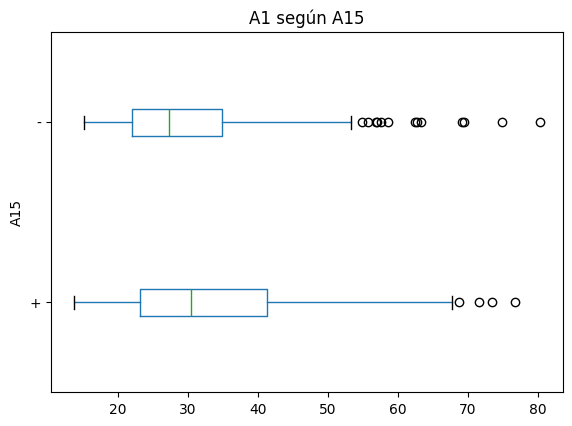

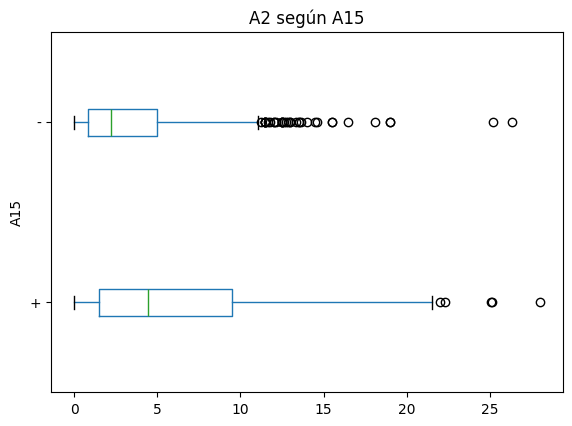

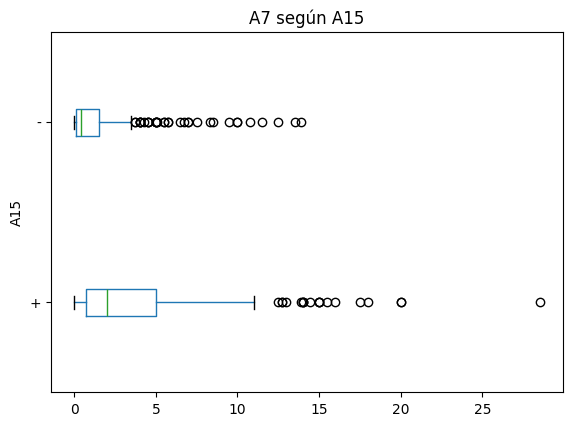

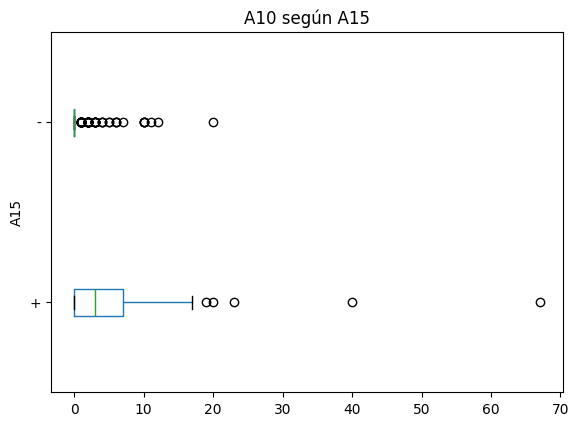

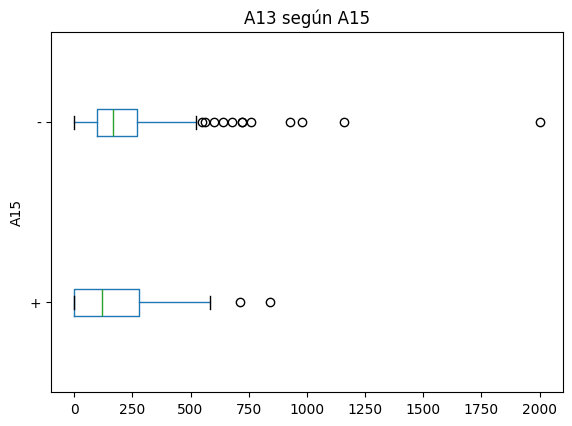

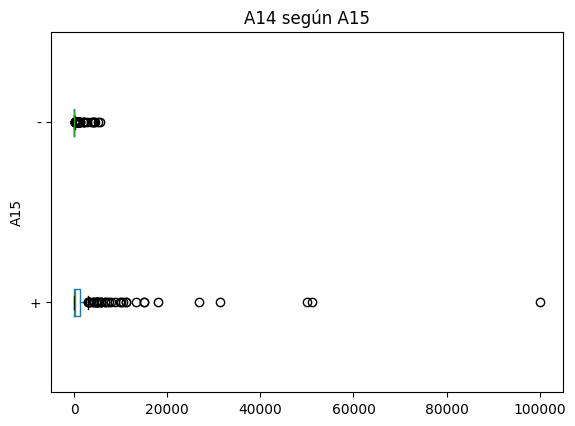

In [ ]:
import matplotlib.pyplot as plt

print("Variables cuantitativas: ", num_vars.values)
print("Variables cualitativas: ", cat_vars.values)


for col in num_vars:
    df.boxplot(
        column=col,
        by='A15',
        grid=False,
        vert=False
    )

    plt.title(f'{col} según A15')
    plt.suptitle('')
    plt.show()


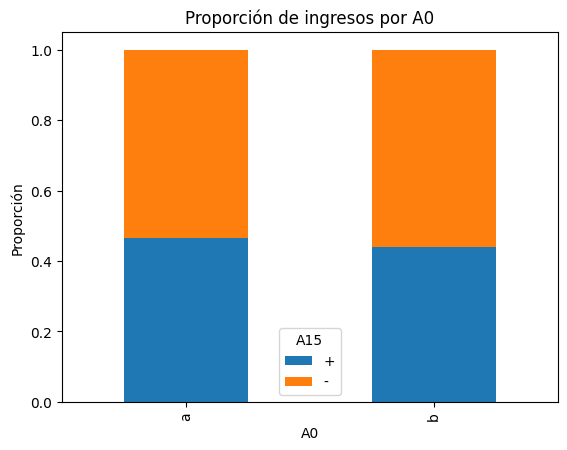

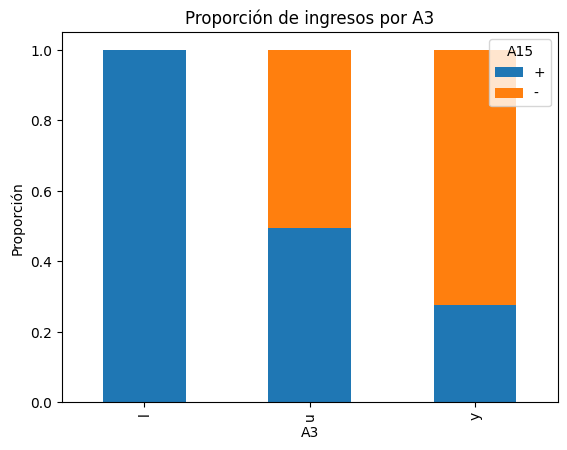

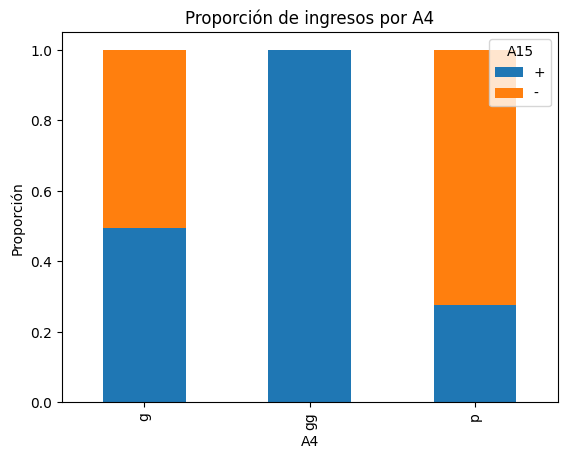

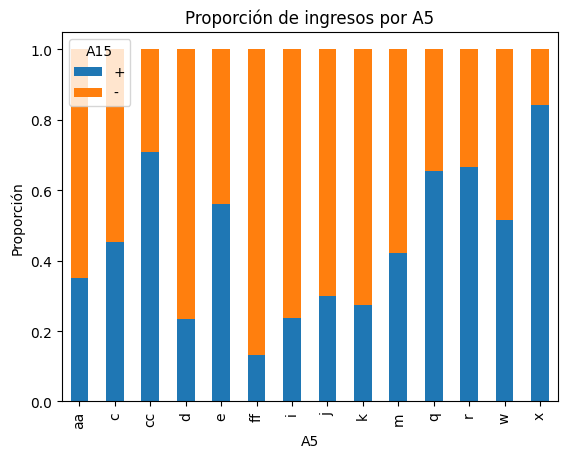

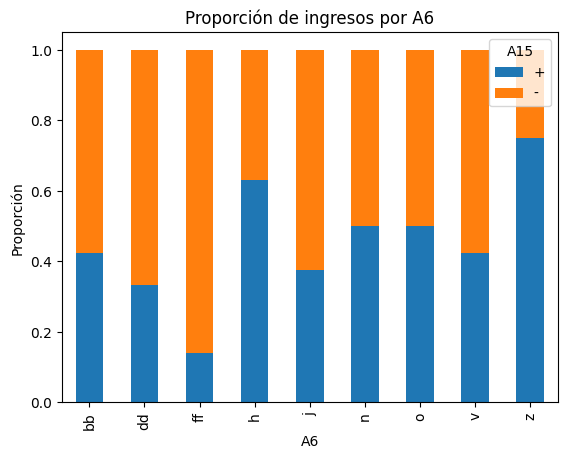

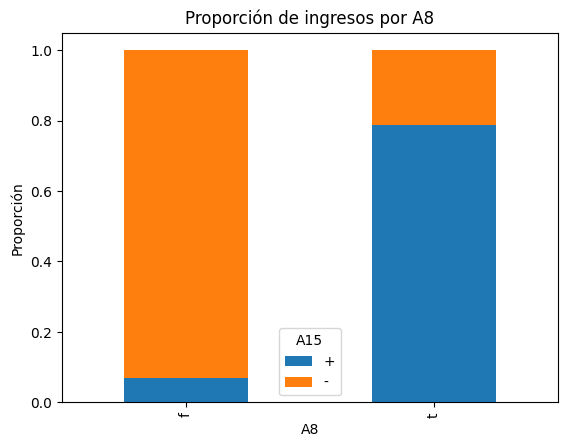

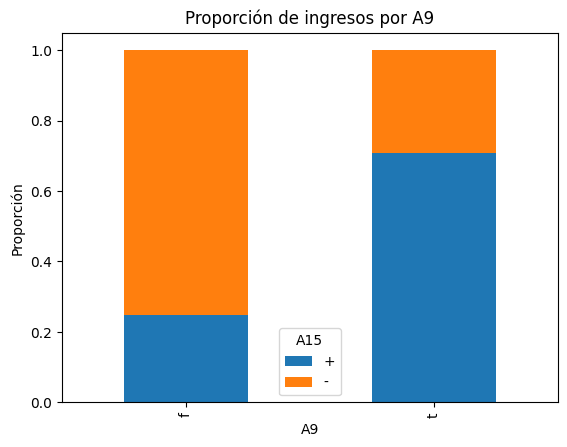

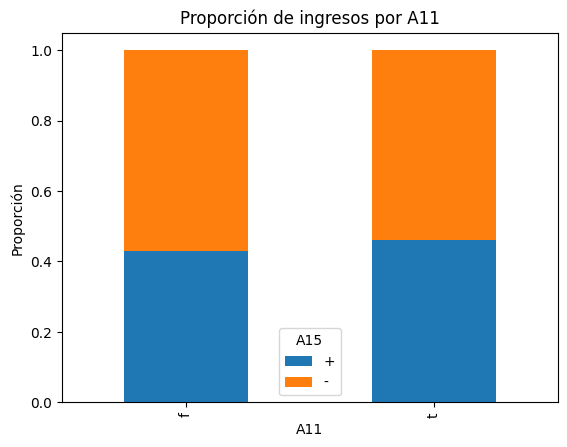

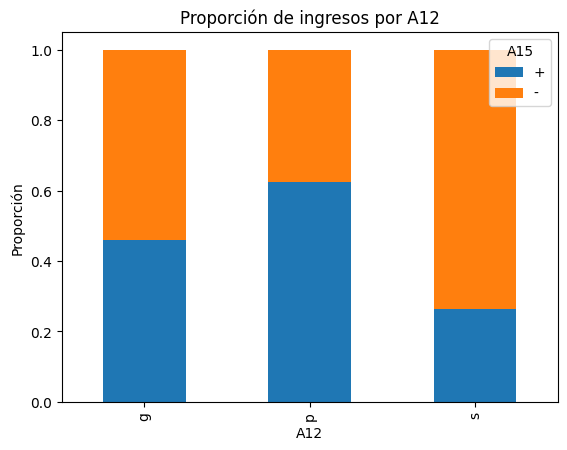

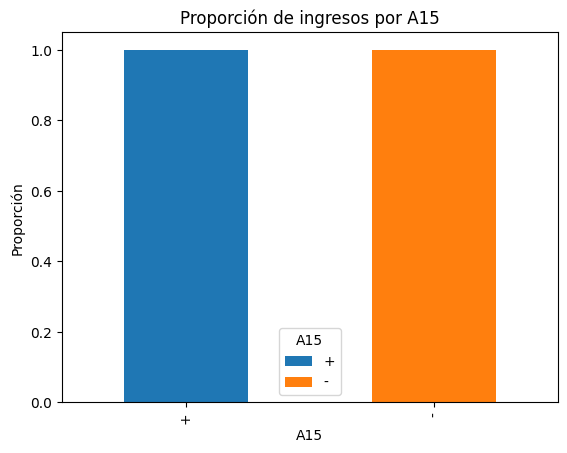

In [ ]:
for var in cat_vars:
    tabla = pd.crosstab(df[var], df['A15'], normalize='index')
    tabla.plot.bar(stacked=True)
    plt.title(f'Proporción de ingresos por {var}')
    plt.ylabel('Proporción')
    plt.show()

<Axes: >

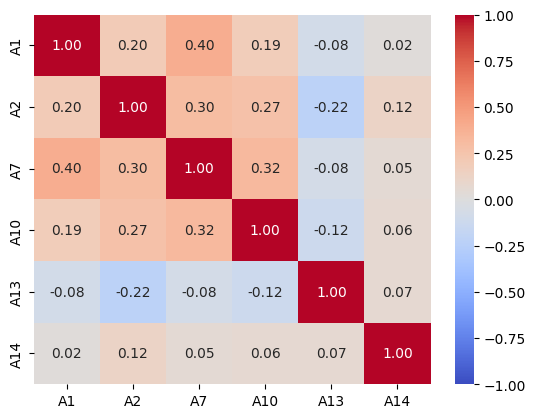

In [ ]:
import seaborn as sns

corr = df.select_dtypes('number').corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)

## Respuestas punto 6
- Para analizar la relación entre las variables cuantitativas y la variable objetivo, A15, se utilizaron diagramas de caja. Consideramos que A2, A7 Y A10 tienen diferencias más evidentes observadas en comparación con sus medianas tienen una mayor relación. A1 tiene menore diferencias por lo que su relación parece débil, al igual que A13 con distribuciones bastantes similares. A14 presenta varios valores atípicos y una mayor concentración lo que no permite ver una separación clara en las categorías.
- Para analizar la relación entre las variables cualitativas y la variable objetivo, A15, se utilizaron diagramas de caja. Consideramos que A0 y A11 presentan una relación débil ya que las proporciones de "+" y "-" ya que son muy similares. A3,A4,A5,A6 y A12 tienen diferencias importantes en las proporciones comparados con A15, lo cual muestra una relación fuerte. A8 y A9 son las variables que mas tienen una relación más marcada ya que se puede observar una gran diferencia en las categorías
- Las variables que se observó que son buenas predictoras son A2,A7,A10,A3,A4,A5,A6,A8,A9, A12 y A14 con una capacidad predictora más intermedia. Las malas predictoras son A0,A1,A11,A13